# Task 3: Multimodal ML – Housing Price Prediction Using Images + Tabular Data


Install & Import Dependencies

In [1]:
# Install required libraries
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu -q
!pip install scikit-learn pandas numpy matplotlib seaborn Pillow tqdm -q
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageDraw, ImageFilter
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {DEVICE}")
print(f"🔢  PyTorch version: {torch.__version__}")

🖥️  Device: cuda
🔢  PyTorch version: 2.10.0+cu128


Generate Synthetic Housing Dataset

In [3]:
# ─── Configuration ────────────────────────────────────────────────────
N_SAMPLES     = 800        # total houses in dataset
IMG_DIR       = Path("house_images")
IMG_SIZE      = (128, 128) # resize all images to this
IMG_DIR.mkdir(exist_ok=True)

# ─── 2A. Tabular data generation ──────────────────────────────────────
np.random.seed(SEED)

neighborhoods = ['Downtown', 'Suburbs', 'Rural', 'Uptown', 'Midtown']
house_types   = ['Detached', 'Semi-Detached', 'Apartment', 'Townhouse']

sqft          = np.random.randint(600, 5000, N_SAMPLES)
bedrooms      = np.random.randint(1, 7, N_SAMPLES)
bathrooms     = np.random.randint(1, 5, N_SAMPLES)
age_years     = np.random.randint(0, 80, N_SAMPLES)
garage        = np.random.randint(0, 4, N_SAMPLES)
neighborhood  = np.random.choice(neighborhoods, N_SAMPLES)
house_type    = np.random.choice(house_types, N_SAMPLES)
lot_size      = np.random.randint(1000, 20000, N_SAMPLES)
floors        = np.random.randint(1, 4, N_SAMPLES)
pool          = np.random.choice([0, 1], N_SAMPLES, p=[0.8, 0.2])

# Neighbourhood multipliers (simulate real estate pricing)
nbhd_mult = {'Downtown': 1.5, 'Uptown': 1.4, 'Midtown': 1.2,
              'Suburbs': 1.0, 'Rural': 0.7}
type_mult = {'Detached': 1.3, 'Semi-Detached': 1.1,
              'Townhouse': 1.0, 'Apartment': 0.85}

base_price = (sqft * 150
              + bedrooms * 8_000
              + bathrooms * 5_000
              - age_years * 1_500
              + garage * 10_000
              + lot_size * 3
              + floors * 5_000
              + pool * 20_000)

nbhd_factors = np.array([nbhd_mult[n] for n in neighborhood])
type_factors = np.array([type_mult[t] for t in house_type])
noise        = np.random.normal(0, 15_000, N_SAMPLES)

price = (base_price * nbhd_factors * type_factors + noise).clip(50_000, 2_000_000)

df = pd.DataFrame({
    'house_id'    : [f'house_{i:04d}' for i in range(N_SAMPLES)],
    'sqft'        : sqft,
    'bedrooms'    : bedrooms,
    'bathrooms'   : bathrooms,
    'age_years'   : age_years,
    'garage_spots': garage,
    'lot_size'    : lot_size,
    'floors'      : floors,
    'pool'        : pool,
    'neighborhood': neighborhood,
    'house_type'  : house_type,
    'price'       : price.astype(int)
})

print(f"📋 Tabular dataset: {df.shape[0]} rows × {df.shape[1]} cols")
df.head()

📋 Tabular dataset: 800 rows × 12 cols


,house_id,sqft,bedrooms,bathrooms,age_years,garage_spots,lot_size,floors,pool,neighborhood,house_type,price
0,house_0000,1460,6,1,13,2,14272,2,0,Uptown,Semi-Detached,506539
1,house_0001,4372,1,1,64,3,6552,2,0,Downtown,Apartment,815146
2,house_0002,3692,1,2,79,3,1627,2,0,Downtown,Semi-Detached,820491
3,house_0003,1066,5,1,53,3,12989,2,0,Rural,Semi-Detached,156501
4,house_0004,4044,5,1,51,0,14780,1,0,Suburbs,Townhouse,630598


In [4]:
def generate_house_image(house_id: str, price: float,
                          house_type: str, size: tuple = (128, 128)) -> None:
    """Create a synthetic RGB image whose colour palette reflects house value."""
    img    = Image.new('RGB', size, color=(220, 220, 220))
    draw   = ImageDraw.Draw(img)
    W, H   = size

    pnorm  = min(price / 2_000_000, 1.0)

    sky_r  = int(100 + pnorm * 80)
    sky_g  = int(149 + pnorm * 50)
    sky_b  = int(237 + pnorm * 18)
    for y in range(H // 2):
        frac = y / (H // 2)
        draw.line([(0, y), (W, y)],
                  fill=(int(sky_r * frac + 255 * (1 - frac)),
                        int(sky_g * frac + 255 * (1 - frac)),
                        int(sky_b * frac + 255 * (1 - frac))))

    # Ground
    ground_g = int(100 + pnorm * 50)
    draw.rectangle([0, H // 2, W, H],
                   fill=(50, ground_g, 30))

    # House body
    wall_r = int(180 + pnorm * 60)
    wall_g = int(120 + pnorm * 80)
    wall_b = int(80  + pnorm * 80)
    draw.rectangle([W//6, H//3, 5*W//6, 4*H//5],
                   fill=(wall_r, wall_g, wall_b), outline=(0, 0, 0))

    # Roof
    roof_r = int(150 - pnorm * 50)
    draw.polygon([(W//6, H//3), (W//2, H//8), (5*W//6, H//3)],
                 fill=(roof_r, 60, 60), outline=(0, 0, 0))

    # Door
    draw.rectangle([W*2//5, 3*H//5, W*3//5, 4*H//5],
                   fill=(80, 50, 20), outline=(0, 0, 0))

    # Windows
    for wx in [W//5, 3*W//5]:
        draw.rectangle([wx, H//3 + 10, wx + W//8, H//3 + 10 + H//10],
                       fill=(200, 230, 255), outline=(0, 0, 0))

    # Pool indicator
    if 'pool' in house_id or pnorm > 0.7:
        draw.ellipse([W*3//4, H*3//5, W - 5, H*4//5],
                     fill=(100, 180, 255), outline=(0, 0, 100))

    # Light blur for realism
    img = img.filter(ImageFilter.GaussianBlur(radius=0.8))
    img.save(IMG_DIR / f"{house_id}.jpg", quality=85)

print("🖼️  Generating synthetic house images …")
for _, row in tqdm(df.iterrows(), total=len(df)):
    generate_house_image(row['house_id'], row['price'], row['house_type'])

print(f"✅ {len(list(IMG_DIR.glob('*.jpg')))} images saved to '{IMG_DIR}/'")

🖼️  Generating synthetic house images …


  0%|          | 0/800 [00:00<?, ?it/s]

✅ 800 images saved to 'house_images/'


Exploratory Data Analysis (EDA)

In [5]:
print("=" * 55)
print(" DATASET SUMMARY")
print("=" * 55)
print(df.describe().round(2).to_string())
print("\nMissing values:", df.isnull().sum().sum())

 DATASET SUMMARY
          sqft  bedrooms  bathrooms  age_years  garage_spots  lot_size  floors    pool       price
count   800.00    800.00     800.00     800.00        800.00    800.00  800.00  800.00      800.00
mean   2826.98      3.46       2.47      37.61          1.50  10682.68    1.99    0.19   562787.42
std    1224.41      1.72       1.11      22.64          1.13   5457.22    0.82    0.40   279119.80
min     603.00      1.00       1.00       0.00          0.00   1016.00    1.00    0.00    51001.00
25%    1780.25      2.00       2.00      18.00          0.00   5987.00    1.00    0.00   347524.50
50%    2796.50      3.00       2.00      37.50          2.00  10609.00    2.00    0.00   525757.50
75%    3862.25      5.00       3.00      57.00          3.00  15320.25    3.00    0.00   742018.00
max    4989.00      6.00       4.00      79.00          3.00  19925.00    3.00    1.00  1510750.00

Missing values: 0


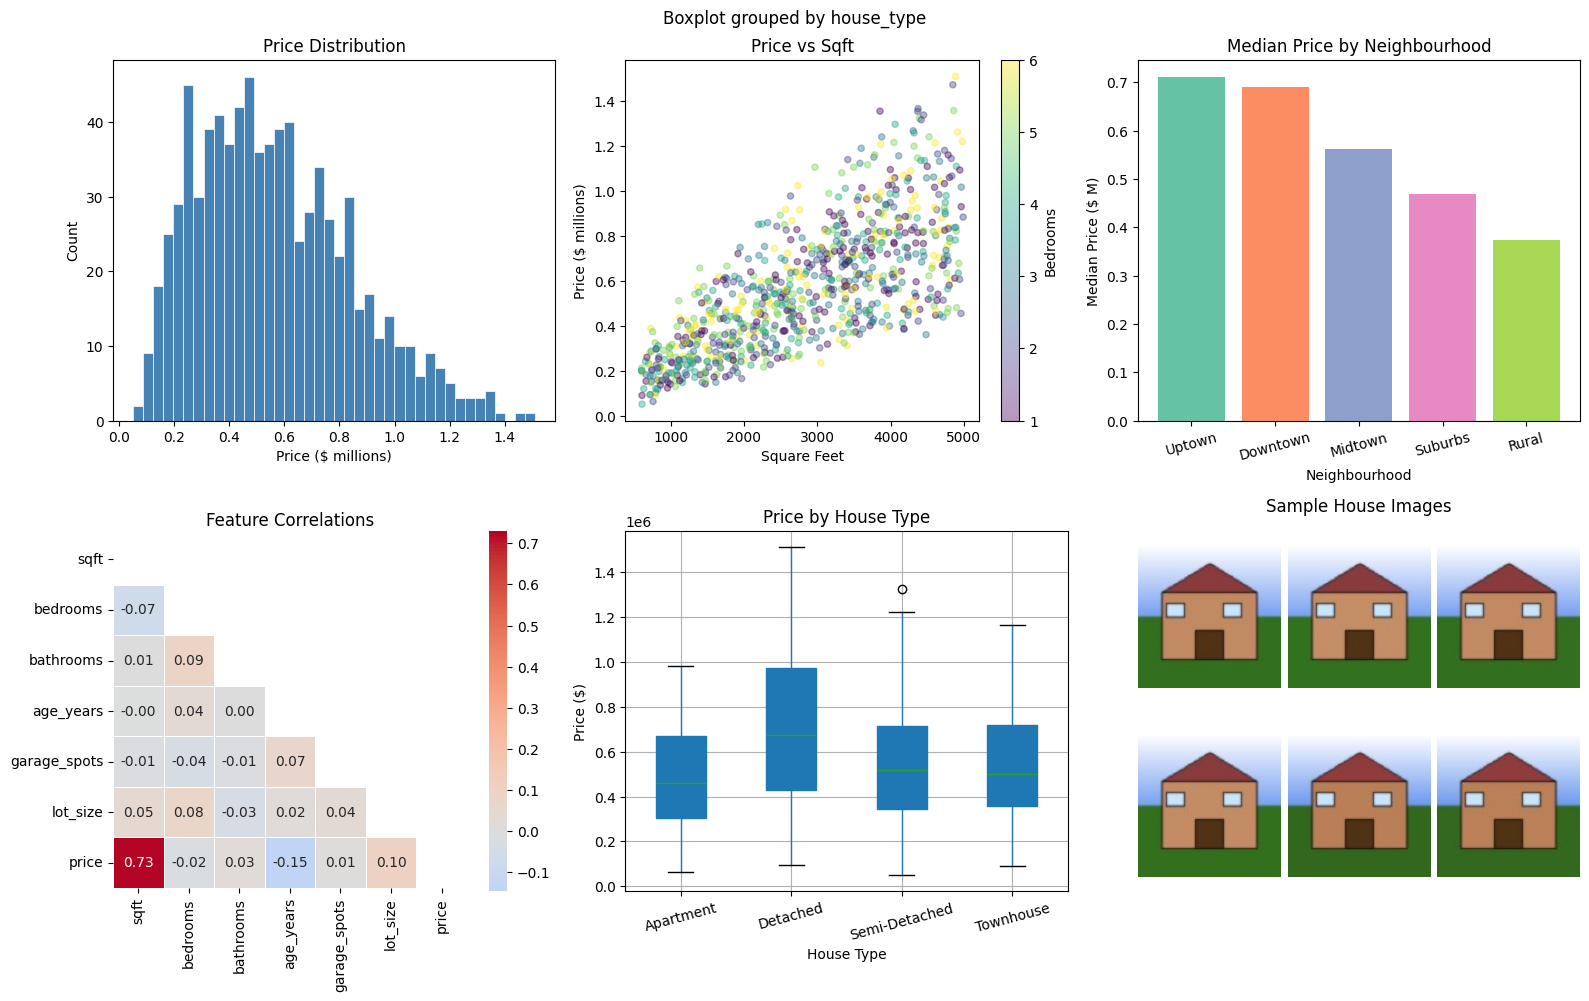

📊 EDA plots saved.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Housing Dataset – EDA', fontsize=16, fontweight='bold', y=1.01)

#Price distribution
axes[0, 0].hist(df['price'] / 1e6, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($ millions)')
axes[0, 0].set_ylabel('Count')

#Price vs sqft
sc = axes[0, 1].scatter(df['sqft'], df['price'] / 1e6, alpha=0.4, c=df['bedrooms'], cmap='viridis', s=20)
plt.colorbar(sc, ax=axes[0, 1], label='Bedrooms')
axes[0, 1].set_title('Price vs Sqft')
axes[0, 1].set_xlabel('Square Feet')
axes[0, 1].set_ylabel('Price ($ millions)')

#Median price by neighbourhood
nbhd_price = df.groupby('neighborhood')['price'].median().sort_values(ascending=False) / 1e6
axes[0, 2].bar(nbhd_price.index, nbhd_price.values, color=sns.color_palette('Set2', len(nbhd_price)))
axes[0, 2].set_title('Median Price by Neighbourhood')
axes[0, 2].set_xlabel('Neighbourhood')
axes[0, 2].set_ylabel('Median Price ($ M)')
axes[0, 2].tick_params(axis='x', rotation=15)

#Correlation heatmap
num_cols = ['sqft', 'bedrooms', 'bathrooms', 'age_years', 'garage_spots', 'lot_size', 'price']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1, 0], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, square=True)
axes[1, 0].set_title('Feature Correlations')

#Price by house type
df.boxplot(column='price', by='house_type', ax=axes[1, 1], patch_artist=True)
axes[1, 1].set_title('Price by House Type')
axes[1, 1].set_xlabel('House Type')
axes[1, 1].set_ylabel('Price ($)')
plt.sca(axes[1, 1]); plt.xticks(rotation=15)

ax = axes[1, 2]
ax.axis('off')
sample_ids = df.sample(6, random_state=SEED)['house_id'].tolist()
inner_gs   = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=axes[1, 2].get_subplotspec(), hspace=0.1, wspace=0.05)
for idx, hid in enumerate(sample_ids):
    inner_ax = fig.add_subplot(inner_gs[idx // 3, idx % 3])
    inner_ax.imshow(Image.open(IMG_DIR / f"{hid}.jpg"))
    inner_ax.axis('off')
axes[1, 2].set_title('Sample House Images', pad=14)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 EDA plots saved.")

Data Preprocessing

In [8]:
le_nbhd = LabelEncoder()
le_type = LabelEncoder()

df['neighborhood_enc'] = le_nbhd.fit_transform(df['neighborhood'])
df['house_type_enc']   = le_type.fit_transform(df['house_type'])

TABULAR_FEATURES = ['sqft', 'bedrooms', 'bathrooms', 'age_years',
                    'garage_spots', 'lot_size', 'floors', 'pool',
                    'neighborhood_enc', 'house_type_enc']
TARGET = 'price'

X_tab = df[TABULAR_FEATURES].values.astype(np.float32)
y     = np.log1p(df[TARGET].values).astype(np.float32)   # log-scale price
img_paths = [str(IMG_DIR / f"{hid}.jpg") for hid in df['house_id']]

idx = np.arange(len(df))
idx_train, idx_tmp  = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_val,   idx_test = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_tab[idx_train])
X_val   = scaler.transform(X_tab[idx_val])
X_test  = scaler.transform(X_tab[idx_test])

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")
print(f"Tabular features: {len(TABULAR_FEATURES)}")
print(f"Target (log price) – mean: {y.mean():.3f}, std: {y.std():.3f}")

Train: 560 | Val: 120 | Test: 120
Tabular features: 10
Target (log price) – mean: 13.103, std: 0.554


Custom PyTorch Dataset

In [9]:
class HousingDataset(Dataset):
    """Multimodal dataset returning (image_tensor, tabular_tensor, price)."""

    TRAIN_TRANSFORMS = transforms.Compose([
        transforms.Resize((IMG_SIZE[0] + 16, IMG_SIZE[1] + 16)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])

    EVAL_TRANSFORMS = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])

    def __init__(self, img_paths, X_tab, y, augment: bool = False):
        self.img_paths  = img_paths
        self.X_tab      = torch.tensor(X_tab, dtype=torch.float32)
        self.y          = torch.tensor(y, dtype=torch.float32)
        self.transforms = self.TRAIN_TRANSFORMS if augment else self.EVAL_TRANSFORMS

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        img   = Image.open(self.img_paths[i]).convert('RGB')
        img_t = self.transforms(img)
        return img_t, self.X_tab[i], self.y[i]


BATCH = 32

train_ds = HousingDataset([img_paths[i] for i in idx_train], X_train, y[idx_train], augment=True)
val_ds   = HousingDataset([img_paths[i] for i in idx_val],   X_val,   y[idx_val])
test_ds  = HousingDataset([img_paths[i] for i in idx_test],  X_test,  y[idx_test])

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

#Sanity check
imgs, tabs, prices = next(iter(train_loader))
print(f"Batch shapes → images: {imgs.shape} | tabular: {tabs.shape} | prices: {prices.shape}")

Batch shapes → images: torch.Size([32, 3, 128, 128]) | tabular: torch.Size([32, 10]) | prices: torch.Size([32])


Multimodal Model Architecture


In [10]:
class ImageBranch(nn.Module):
    """ResNet-18 backbone with frozen early layers and a projection head."""

    def __init__(self, out_dim: int = 256, freeze_up_to: str = 'layer2'):
        super().__init__()
        backbone      = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-1])  # drop final FC
        cnn_out_dim   = backbone.fc.in_features  # 512

        # Freeze early layers
        freeze = True
        for name, param in backbone.named_parameters():
            if freeze_up_to in name:
                freeze = False
            param.requires_grad = not freeze

        self.proj = nn.Sequential(
            nn.Linear(cnn_out_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

    def forward(self, x):
        feat = self.features(x).flatten(1)
        return self.proj(feat)


class TabularBranch(nn.Module):
    """Small MLP for structured/tabular features."""

    def __init__(self, in_dim: int, out_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

    def forward(self, x):
        return self.net(x)


class MultimodalHousePricer(nn.Module):
    """Fuses CNN image features with tabular features for price regression."""

    def __init__(self, tab_in: int, img_out: int = 256, tab_out: int = 128):
        super().__init__()
        self.image_branch   = ImageBranch(out_dim=img_out)
        self.tabular_branch = TabularBranch(in_dim=tab_in, out_dim=tab_out)
        fused_dim = img_out + tab_out

        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, images, tabular):
        img_feat = self.image_branch(images)
        tab_feat = self.tabular_branch(tabular)
        fused    = torch.cat([img_feat, tab_feat], dim=1)
        return self.fusion(fused).squeeze(1)


model = MultimodalHousePricer(tab_in=len(TABULAR_FEATURES)).to(DEVICE)
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📐 Total params    : {total_params:,}")
print(f"🔓 Trainable params: {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


📐 Total params    : 11,433,345
🔓 Trainable params: 11,275,841  (98.6%)


Training Loop

In [11]:
def run_epoch(model, loader, optimizer=None, criterion=None, train=True):
    """Single epoch forward (and optionally backward) pass."""
    model.train(train)
    total_loss, n = 0.0, 0
    all_preds, all_targets = [], []

    with torch.set_grad_enabled(train):
        for imgs, tabs, targets in loader:
            imgs, tabs, targets = imgs.to(DEVICE), tabs.to(DEVICE), targets.to(DEVICE)
            preds = model(imgs, tabs)
            loss  = criterion(preds, targets)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(targets)
            n          += len(targets)
            all_preds.extend(preds.cpu().detach().numpy())
            all_targets.extend(targets.cpu().numpy())

    return total_loss / n, np.array(all_preds), np.array(all_targets)

EPOCHS   = 30
LR       = 3e-4
WD       = 1e-4
PATIENCE = 6

criterion = nn.HuberLoss(delta=0.5)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR / 20)

history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss = float('inf')
patience_cnt  = 0

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val MAE ($K)':>12} | LR")
print("-" * 58)

for epoch in range(1, EPOCHS + 1):
    tr_loss, _, _           = run_epoch(model, train_loader, optimizer, criterion, train=True)
    val_loss, vp, vt        = run_epoch(model, val_loader,   optimizer, criterion, train=False)
    scheduler.step()

    vp_dollar = np.expm1(vp)
    vt_dollar = np.expm1(vt)
    val_mae_k = mean_absolute_error(vt_dollar, vp_dollar) / 1_000

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae_k)

    cur_lr = scheduler.get_last_lr()[0]
    print(f"{epoch:>5} | {tr_loss:>10.4f} | {val_loss:>10.4f} | {val_mae_k:>10.1f} K | {cur_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\n⏹️  Early stopping at epoch {epoch}.")
            break

print("\n✅ Training complete. Best val loss:", round(best_val_loss, 4))

Epoch | Train Loss |   Val Loss | Val MAE ($K) | LR
----------------------------------------------------------
    1 |     5.3678 |     4.4452 |      546.6 K | 2.99e-04
    2 |     4.0040 |     3.2297 |      546.0 K | 2.97e-04
    3 |     2.7556 |     1.9470 |      539.0 K | 2.93e-04
    4 |     1.4175 |     0.5921 |      431.7 K | 2.88e-04
    5 |     0.4441 |     0.1780 |      290.6 K | 2.81e-04
    6 |     0.3465 |     0.1095 |      200.2 K | 2.73e-04
    7 |     0.3139 |     0.0830 |      178.2 K | 2.63e-04
    8 |     0.3304 |     0.0586 |      146.8 K | 2.53e-04
    9 |     0.3007 |     0.0473 |      133.2 K | 2.41e-04
   10 |     0.2853 |     0.0488 |      126.1 K | 2.29e-04
   11 |     0.2818 |     0.0560 |      130.4 K | 2.15e-04
   12 |     0.3266 |     0.0359 |      102.7 K | 2.02e-04
   13 |     0.2822 |     0.0370 |      119.5 K | 1.87e-04
   14 |     0.2685 |     0.0323 |      108.7 K | 1.72e-04
   15 |     0.2703 |     0.0476 |      135.1 K | 1.58e-04
   16 |     0.2956 

Training Curves

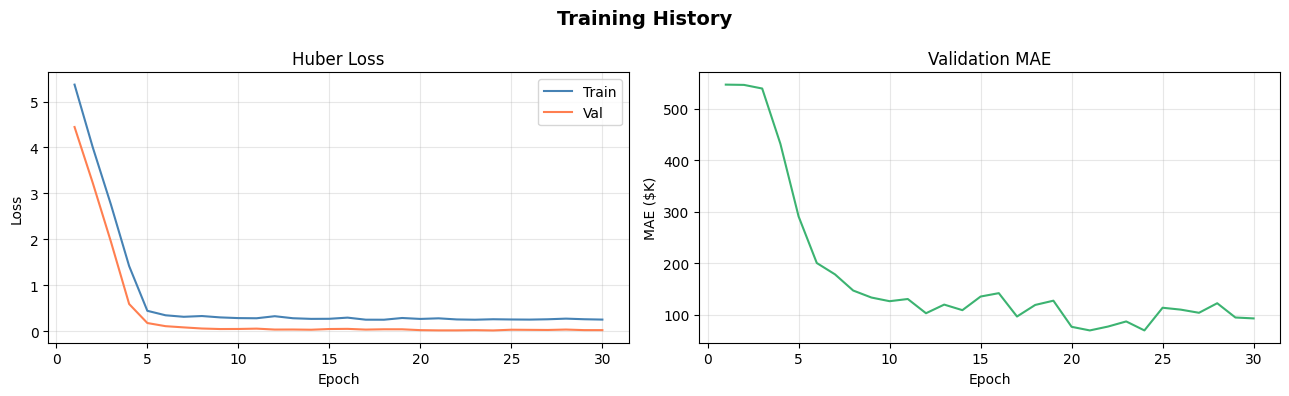

In [12]:
epochs_ran = len(history['train_loss'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

ax1.plot(range(1, epochs_ran + 1), history['train_loss'], label='Train', color='steelblue')
ax1.plot(range(1, epochs_ran + 1), history['val_loss'],   label='Val',   color='coral')
ax1.set_title('Huber Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(range(1, epochs_ran + 1), history['val_mae'], color='mediumseagreen')
ax2.set_title('Validation MAE'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE ($K)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

Model Evaluation – MAE & RMSE

In [13]:
# Load best checkpoint
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))

_, test_preds_log, test_true_log = run_epoch(
    model, test_loader, criterion=criterion, train=False)

test_preds = np.expm1(test_preds_log)
test_true  = np.expm1(test_true_log)

mae  = mean_absolute_error(test_true, test_preds)
rmse = np.sqrt(mean_squared_error(test_true, test_preds))
mape = np.mean(np.abs((test_true - test_preds) / test_true)) * 100
r2   = 1 - np.sum((test_true - test_preds)**2) / np.sum((test_true - test_true.mean())**2)

print("=" * 45)
print("  TEST SET EVALUATION METRICS")
print("=" * 45)
print(f"  MAE  : ${mae:>12,.0f}")
print(f"  RMSE : ${rmse:>12,.0f}")
print(f"  MAPE : {mape:>11.2f}%")
print(f"  R²   : {r2:>12.4f}")
print("=" * 45)

  TEST SET EVALUATION METRICS
  MAE  : $      77,003
  RMSE : $      98,465
  MAPE :       16.55%
  R²   :       0.8871


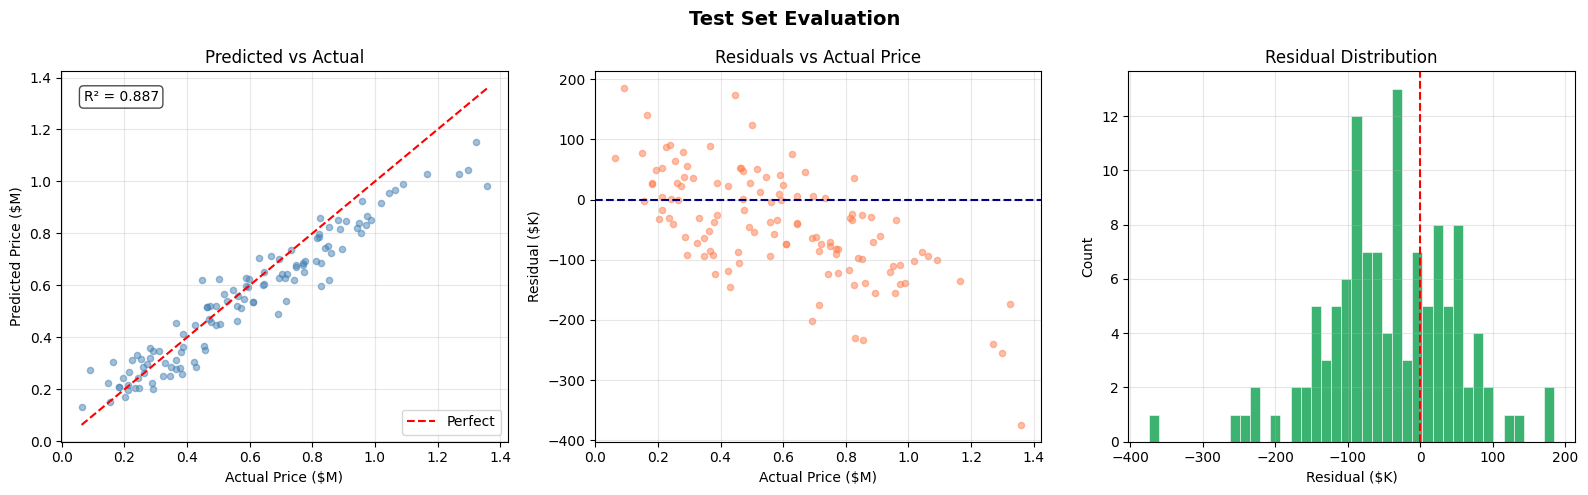

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Test Set Evaluation', fontsize=14, fontweight='bold')

#Predicted vs Actual
mn, mx = test_true.min(), test_true.max()
axes[0].scatter(test_true / 1e6, test_preds / 1e6, alpha=0.5, s=20, color='steelblue')
axes[0].plot([mn / 1e6, mx / 1e6], [mn / 1e6, mx / 1e6], 'r--', linewidth=1.5, label='Perfect')
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual Price ($M)')
axes[0].set_ylabel('Predicted Price ($M)')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.92, f'R² = {r2:.3f}', transform=axes[0].transAxes,
             fontsize=10, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

#Residuals
residuals = test_preds - test_true
axes[1].scatter(test_true / 1e6, residuals / 1e3, alpha=0.5, s=20, color='coral')
axes[1].axhline(0, color='navy', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Actual Price')
axes[1].set_xlabel('Actual Price ($M)')
axes[1].set_ylabel('Residual ($K)')
axes[1].grid(alpha=0.3)

#Error distribution
axes[2].hist(residuals / 1e3, bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.4)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual ($K)')
axes[2].set_ylabel('Count')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()

Image-Only vs Tabular-Only vs Multimodal

In [15]:
class ImageOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch = ImageBranch(out_dim=256)
        self.head   = nn.Sequential(nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, images, tabular):
        return self.head(self.branch(images)).squeeze(1)


class TabularOnlyModel(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.branch = TabularBranch(in_dim=in_dim, out_dim=128)
        self.head   = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, images, tabular):
        return self.head(self.branch(tabular)).squeeze(1)


def quick_train_eval(model_class, name, epochs=15, **kwargs):
    m   = model_class(**kwargs).to(DEVICE)
    opt = optim.AdamW(filter(lambda p: p.requires_grad, m.parameters()),
                      lr=3e-4, weight_decay=1e-4)
    crit = nn.HuberLoss(delta=0.5)
    for _ in range(epochs):
        run_epoch(m, train_loader, opt, crit, train=True)

    _, plog, tlog = run_epoch(m, test_loader, criterion=crit, train=False)
    p, t = np.expm1(plog), np.expm1(tlog)
    mae  = mean_absolute_error(t, p)
    rmse = np.sqrt(mean_squared_error(t, p))
    r2   = 1 - np.sum((t - p)**2) / np.sum((t - t.mean())**2)
    print(f"  {name:<15} → MAE: ${mae:>10,.0f} | RMSE: ${rmse:>10,.0f} | R²: {r2:.3f}")
    return {'model': name, 'MAE_K': mae / 1e3, 'RMSE_K': rmse / 1e3, 'R2': r2}


print("\n🔬 Ablation Study (15-epoch quick train)")
print("-" * 62)
results = []
results.append(quick_train_eval(ImageOnlyModel,   'Image Only',    epochs=15))
results.append(quick_train_eval(TabularOnlyModel, 'Tabular Only',  epochs=15, in_dim=len(TABULAR_FEATURES)))

results.append({'model': 'Multimodal (full)',
                'MAE_K': mae / 1e3, 'RMSE_K': rmse / 1e3, 'R2': r2})
print(f"  {'Multimodal (full)':<15} → MAE: ${mae:>10,.0f} | RMSE: ${rmse:>10,.0f} | R²: {r2:.3f}")

ablation_df = pd.DataFrame(results)
print("\n", ablation_df.round(2).to_string(index=False))


🔬 Ablation Study (15-epoch quick train)
--------------------------------------------------------------
  Image Only      → MAE: $   277,457 | RMSE: $   319,424 | R²: -0.188
  Tabular Only    → MAE: $   476,010 | RMSE: $   854,729 | R²: -7.507
  Multimodal (full) → MAE: $    77,003 | RMSE: $    98,465 | R²: 0.887

             model  MAE_K  RMSE_K    R2
       Image Only 277.46  319.42 -0.19
     Tabular Only 476.01  854.73 -7.51
Multimodal (full)  77.00   98.46  0.89


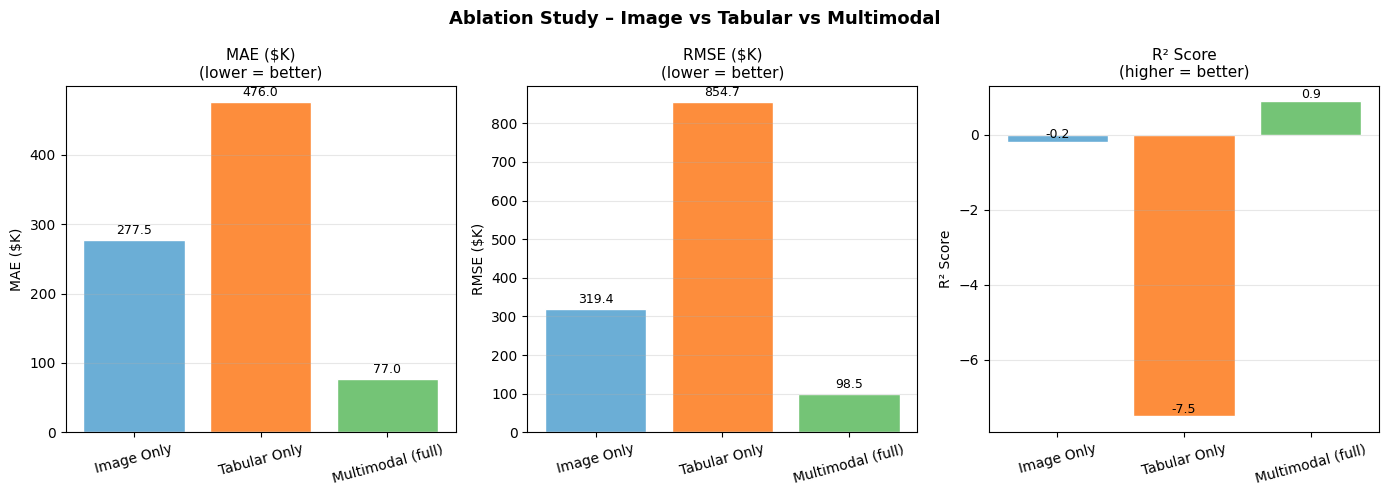

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Ablation Study – Image vs Tabular vs Multimodal', fontsize=13, fontweight='bold')

palette = ['#6baed6', '#fd8d3c', '#74c476']
metrics = [('MAE_K', 'MAE ($K)', 'lower = better'),
           ('RMSE_K', 'RMSE ($K)', 'lower = better'),
           ('R2', 'R² Score', 'higher = better')]

for ax, (col, ylabel, note) in zip(axes, metrics):
    bars = ax.bar(ablation_df['model'], ablation_df[col], color=palette, edgecolor='white')
    ax.set_title(f'{ylabel}\n({note})', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(ablation_df[col]) * 0.01,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=120, bbox_inches='tight')
plt.show()

Feature Importance via Permutation

Baseline MAE: $77,003
  sqft                : Δ MAE = $+81,579
  bedrooms            : Δ MAE = $-529
  bathrooms           : Δ MAE = $+819
  age_years           : Δ MAE = $+11,692
  garage_spots        : Δ MAE = $+576
  lot_size            : Δ MAE = $+1,773
  floors              : Δ MAE = $+1,599
  pool                : Δ MAE = $-957
  neighborhood_enc    : Δ MAE = $+5,252
  house_type_enc      : Δ MAE = $+1,272


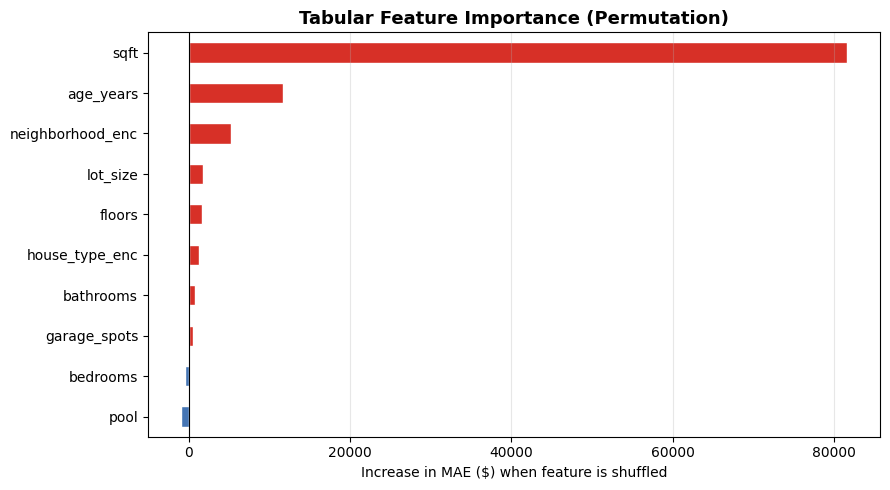

In [17]:
model.eval()

def evaluate_mae_on_test(mdl, loader):
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, tabs, targets in loader:
            preds = mdl(imgs.to(DEVICE), tabs.to(DEVICE))
            all_p.extend(np.expm1(preds.cpu().numpy()))
            all_t.extend(np.expm1(targets.numpy()))
    return mean_absolute_error(all_t, all_p)

base_mae = evaluate_mae_on_test(model, test_loader)
print(f"Baseline MAE: ${base_mae:,.0f}")

importances = {}
for feat_idx, feat_name in enumerate(TABULAR_FEATURES):
    # Shuffle this feature column across test set
    X_test_perturbed = X_test.copy()
    np.random.shuffle(X_test_perturbed[:, feat_idx])

    perm_ds = HousingDataset([img_paths[i] for i in idx_test],
                              X_test_perturbed, y[idx_test])
    perm_loader = DataLoader(perm_ds, batch_size=BATCH, shuffle=False, num_workers=0)
    perm_mae    = evaluate_mae_on_test(model, perm_loader)
    importances[feat_name] = perm_mae - base_mae
    print(f"  {feat_name:<20}: Δ MAE = ${perm_mae - base_mae:+,.0f}")

importance_series = pd.Series(importances).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d73027' if v > 0 else '#4575b4' for v in importance_series.values]
importance_series.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Tabular Feature Importance (Permutation)', fontsize=13, fontweight='bold')
ax.set_xlabel('Increase in MAE ($) when feature is shuffled')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

Visualizations

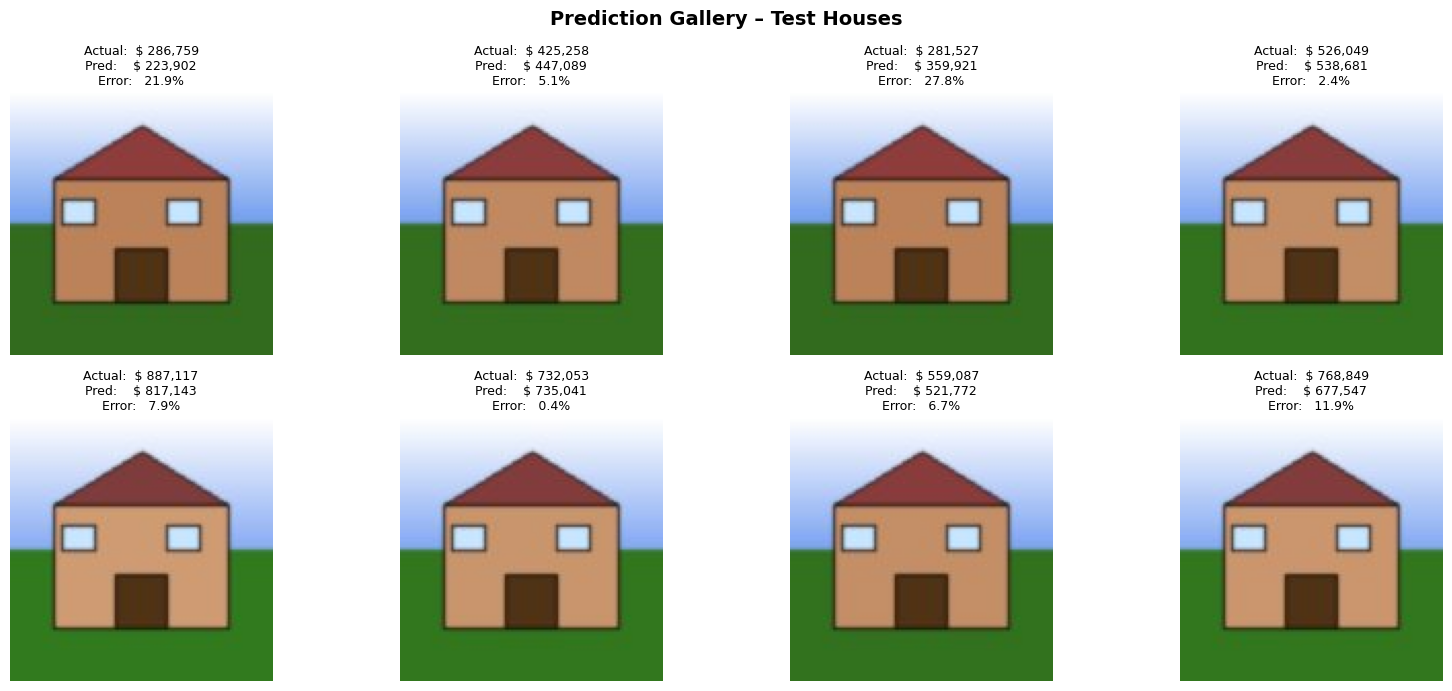

In [18]:
model.eval()
sample_idx = random.sample(list(range(len(test_ds))), 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Prediction Gallery – Test Houses', fontsize=14, fontweight='bold')

for ax, i in zip(axes.flat, sample_idx):
    img_t, tab_t, y_t = test_ds[i]

    with torch.no_grad():
        pred_log = model(img_t.unsqueeze(0).to(DEVICE),
                         tab_t.unsqueeze(0).to(DEVICE)).item()

    pred_price = np.expm1(pred_log)
    true_price = np.expm1(y_t.item())
    err_pct    = abs(pred_price - true_price) / true_price * 100

    # Show the raw image (un-normalise for display)
    img_display = Image.open(test_ds.img_paths[i])
    ax.imshow(img_display)
    ax.set_title(f"Actual:  ${true_price:>8,.0f}\n"
                 f"Pred:    ${pred_price:>8,.0f}\n"
                 f"Error:   {err_pct:.1f}%",
                 fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('prediction_gallery.png', dpi=120, bbox_inches='tight')
plt.show()

Results Summary

In [24]:
print("╔" + "═" * 52 + "╗")
print("║       MULTIMODAL HOUSING PRICE PREDICTION          ║")
print("║               FINAL RESULTS SUMMARY                ║")
print("╠" + "═" * 52 + "╣")
print(f"║  Dataset size        : {N_SAMPLES} houses                  ║")
print(f"║  Tabular features    : {len(TABULAR_FEATURES)}                          ║")
print(f"║  Image size          : {IMG_SIZE[0]}×{IMG_SIZE[1]} px                  ║")
print(f"║  CNN backbone        : ResNet-18 (pretrained)      ║")
print(f"║  Fusion strategy     : Concatenation + MLP         ║")
print("╠" + "═" * 52 + "╣")
print(f"║  Test MAE            : ${mae:>12,.0f}               ║")
print(f"║  Test RMSE           : ${rmse:>12,.0f}               ║")
print(f"║  Test MAPE           : {mape:>10.2f}%                 ║")
print(f"║  Test R²             : {r2:>12.4f}                ║")
print("╚" + "═" * 52 + "╝")

╔════════════════════════════════════════════════════╗
║       MULTIMODAL HOUSING PRICE PREDICTION          ║
║               FINAL RESULTS SUMMARY                ║
╠════════════════════════════════════════════════════╣
║  Dataset size        : 800 houses                  ║
║  Tabular features    : 10                          ║
║  Image size          : 128×128 px                  ║
║  CNN backbone        : ResNet-18 (pretrained)      ║
║  Fusion strategy     : Concatenation + MLP         ║
╠════════════════════════════════════════════════════╣
║  Test MAE            : $      77,003               ║
║  Test RMSE           : $      98,465               ║
║  Test MAPE           :      16.55%                 ║
║  Test R²             :       0.8871                ║
╚════════════════════════════════════════════════════╝
